# Init

## Import

In [49]:
#기초
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Linear Regression & Classification
from sklearn.linear_model import LinearRegression

# Metric
#from sklearn.metrics import accuracy_score, f1_score,classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scaler
from sklearn.preprocessing import StandardScaler

# Grid Search CV
from sklearn.model_selection import GridSearchCV

# Encoder
from sklearn.preprocessing import OneHotEncoder

#XGBoost
from xgboost import XGBRegressor,plot_importance
#Korean
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## Data

In [50]:
df = pd.read_csv("./dataset/sleep_health_dataset.csv")
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


## Data Cleaning

In [51]:
#Gender
gender_mapping = {
   'Male':0,
   'Female':1
}
df['gender'] = df['gender'].map(gender_mapping)

#day_type change
day_mapping = {
   'Weekend': 2,
   'Weekday': 1
}
df['day_type'] = df['day_type'].map(day_mapping)

#Mental Health Condition
mental_mapping={
    'Healthy': 0,
    'Both': 1,
    'Anxiety': 2,
    'Depression': 3
}
df['mental_health_condition'] = df['mental_health_condition'].map(mental_mapping)

#Sleep Disorder Risk
sleep_disorder_mapping={
    'Healthy':0,
    'Mild':1,
    'Moderate':2,
    'Severe':3
}
df['sleep_disorder_risk'] = df['sleep_disorder_risk'].map(sleep_disorder_mapping)
#df.info()

## Encoding

In [52]:
df = df.drop(columns=['person_id','country','occupation','season', 'chronotype','nap_duration_mins','sleep_aid_used','weekend_sleep_diff_hrs','gender','bmi','screen_time_before_bed_mins','room_temperature_celsius'])

## TEST

In [53]:
df.head(30)

,age,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,exercise_day,steps_that_day,stress_score,work_hours_that_day,mental_health_condition,heart_rate_resting_bpm,shift_work,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,29,6.19,6.6,22.5,19.3,16,3,0,0.0,0,6592,4.4,10.7,0,63,0,1,73.4,0,0
1,55,8.32,6.9,26.9,14.9,17,4,0,0.0,1,10111,4.0,3.0,0,52,0,2,99.4,0,1
2,42,3.74,1.0,20.2,16.2,26,4,0,2.0,1,9222,7.8,3.6,1,72,1,2,2.5,3,0
3,37,6.79,6.4,17.7,17.7,13,4,0,1.0,1,9190,4.9,6.7,0,71,0,2,67.8,0,0
4,23,5.02,3.2,23.3,18.3,30,5,40,0.0,0,4273,7.4,10.4,0,71,0,1,38.1,1,0
5,23,8.16,5.7,17.3,20.1,29,2,150,2.0,0,9170,5.5,6.2,3,71,0,2,49.9,1,1
6,20,7.27,5.1,17.5,18.8,31,2,0,3.0,1,10786,5.0,4.3,2,79,0,2,57.9,1,1
7,48,8.04,6.5,25.3,22.3,22,4,150,0.0,1,6194,5.5,2.8,2,60,0,2,92.0,1,0
8,37,6.04,5.4,18.9,15.7,37,0,400,0.0,0,6083,6.0,5.4,2,74,0,2,53.6,1,0
9,41,6.22,4.9,21.4,15.5,24,3,0,0.0,0,5207,5.7,12.7,0,80,0,1,67.8,1,1


# Explatory Data Analysis

## Heatmap

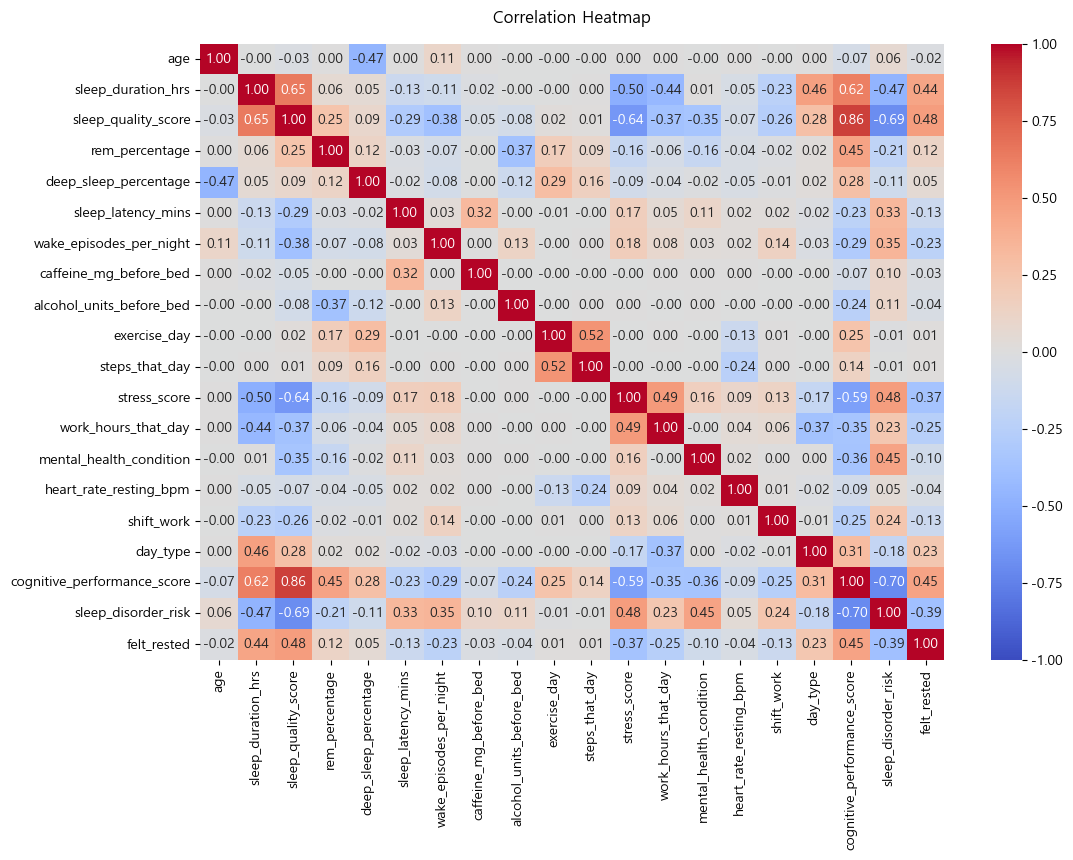

In [54]:
plt.figure(figsize=(12, 8)) 
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
ax = sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap", pad=15)
plt.show()


## Heatmap (Correlation |.3|+)

### Correlation above |.3|

In [55]:
# 1. Calculate correlation matrix
corr_matrix = df.corr()

# 2. Get the correlation of all features with the target
target_corr = corr_matrix['cognitive_performance_score']

# 3. Filter for correlations > 0.3 (using absolute value to include negative correlations)
# We use abs() because a correlation of -0.8 is just as important as +0.8
high_corr_features = target_corr[abs(target_corr) > 0.3].index.tolist()

print(f"Features with > 0.3 correlation: {high_corr_features}")

Features with > 0.3 correlation: ['sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'stress_score', 'work_hours_that_day', 'mental_health_condition', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested']


### Graphing Correlation |.3|+

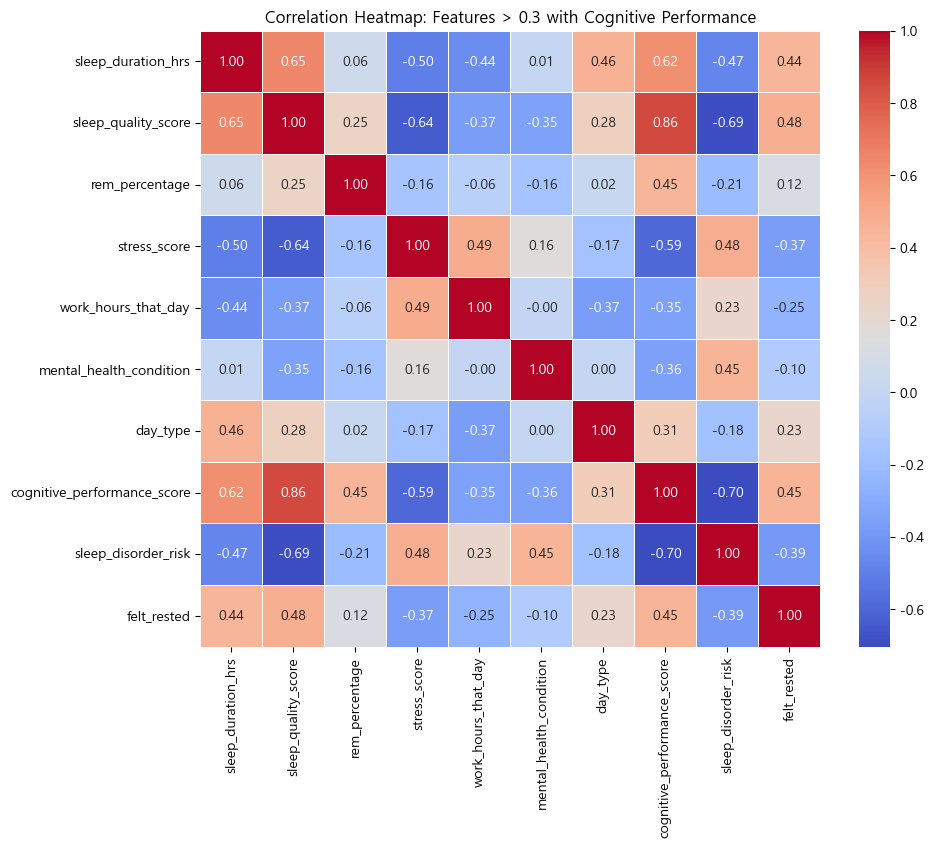

In [56]:
# Create the filtered heatmap
plt.figure(figsize=(10, 8))

# Calculate correlation only for the selected features
filtered_corr = df[high_corr_features].corr()

sns.heatmap(filtered_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap: Features > 0.3 with Cognitive Performance")
plt.show()

## Heatmap 기반 Linear Regression

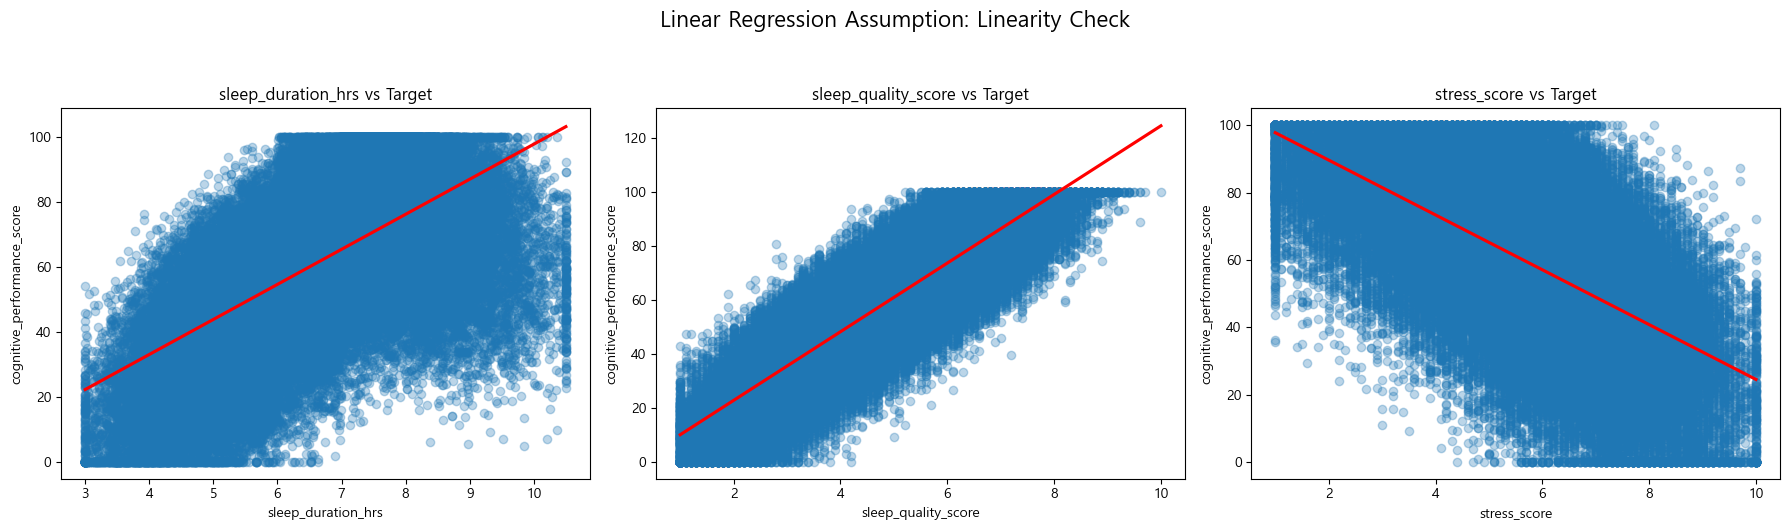

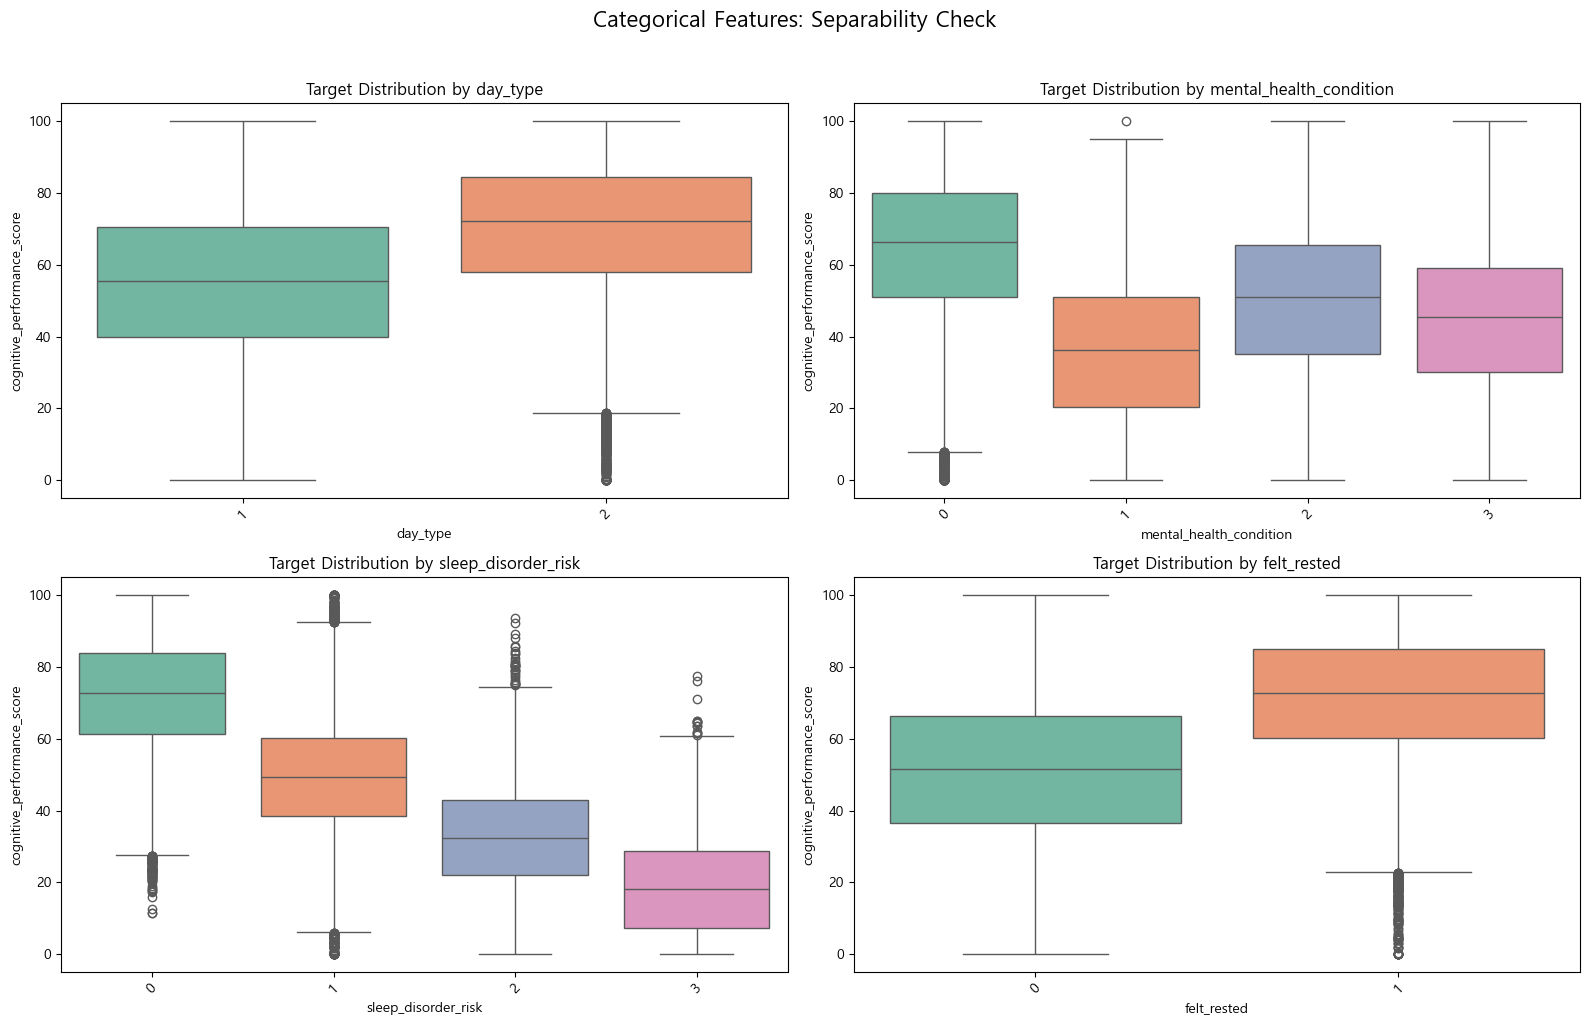

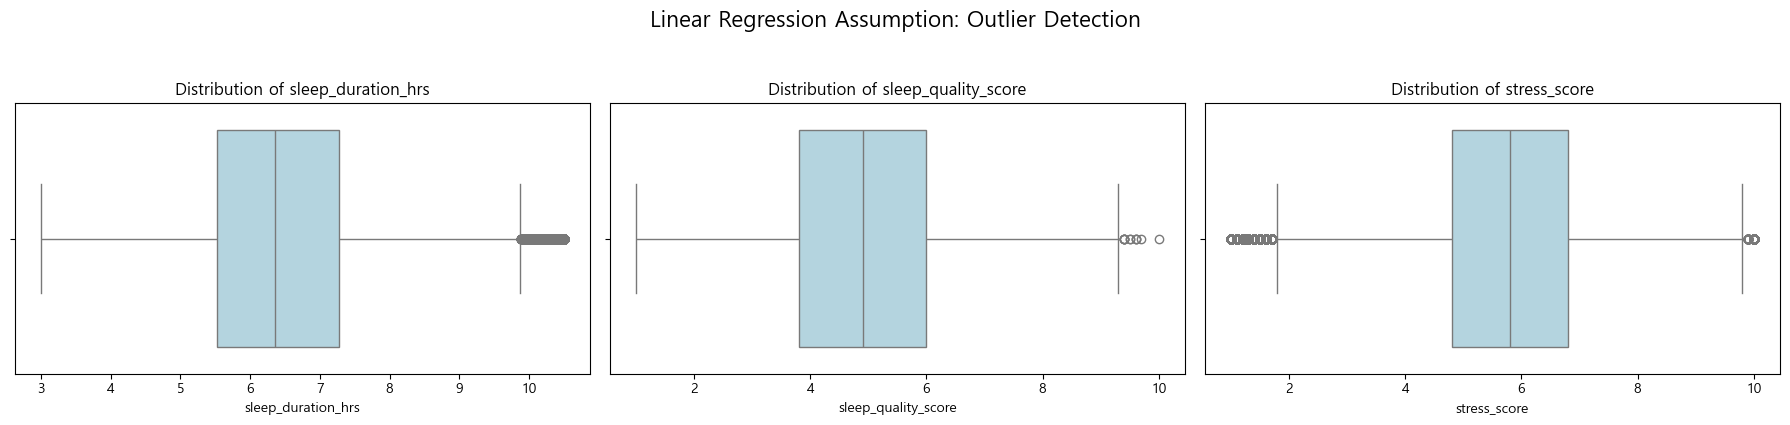

In [57]:
# Define the features you identified from your correlation heatmap
cont_cols = ['sleep_duration_hrs', 'sleep_quality_score', 'stress_score']
cat_cols = ['day_type', 'mental_health_condition', 'sleep_disorder_risk', 'felt_rested']

# =========================================================
# PLOT 1: Linearity Check (1 row, 3 columns)
# 각 수치형 변수가 인지 능력 점수(Target)와 직선 형태의 선형 관계를 갖는지 확인합니다.
# 선형 회귀 모델의 기본 가정을 검토하기 위한 단계입니다.
# =========================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle('Linear Regression Assumption: Linearity Check', fontsize=16, y=1.05)

for i, col in enumerate(cont_cols):
    sns.regplot(
        data=df, 
        x=col, 
        y='cognitive_performance_score', 
        ax=axes1[i], 
        scatter_kws={'alpha': 0.3}, 
        line_kws={'color': 'red'}
    )
    axes1[i].set_title(f'{col} vs Target')
plt.tight_layout()
plt.show()


# =========================================================
# PLOT 2: Categorical Variable Analysis (2 rows, 2 columns)
# 범주형 변수의 각 그룹에 따라 인지 능력 점수의 분포가 명확히 분리되는지 확인합니다.
# 특정 범주가 타겟 변수를 예측하는 데 중요한 구분선이 되는지 파악합니다.
# =========================================================
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10))
fig2.suptitle('Categorical Features: Separability Check', fontsize=16, y=1.02)
axes2 = axes2.flatten() 
for i, col in enumerate(cat_cols):
    if col in df.columns:
        sns.boxplot(
            data=df, 
            x=col, 
            y='cognitive_performance_score', 
            ax=axes2[i], 
            palette='Set2',
            hue=col,          
            legend=False      
        )
        axes2[i].set_title(f'Target Distribution by {col}')
        axes2[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# PLOT 3: Outlier Detection (1 row, 3 columns)
# 수치형 데이터 내에 일반적인 범위를 벗어난 이상치(Outlier)가 있는지 확인합니다.
# 이상치는 선형 회귀 모델의 기울기를 왜곡시킬 수 있으므로 전처리 전 확인이 필수적입니다.
# =========================================================
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 4))
fig3.suptitle('Linear Regression Assumption: Outlier Detection', fontsize=16, y=1.05)

for i, col in enumerate(cont_cols):
    sns.boxplot(
        x=df[col], 
        ax=axes3[i], 
        color='lightblue'
    )
    axes3[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Training

In [58]:
# Correlation 높은 Columns only
target = 'cognitive_performance_score'
features = ['sleep_duration_hrs', 'sleep_quality_score', 'stress_score', 
            'day_type', 'work_hours_that_day', 'mental_health_condition', 
            'sleep_disorder_risk', 'felt_rested']



#dropna 실시
df_model = df[features + [target]].dropna()
#X = df_model[features]
X = df_model.drop(columns=[target]) # 타겟을 제외한 모든 컬럼이 X가 됨

y = df_model[target]

## Train Test Split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Encoding

In [60]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
cat_cols = ['day_type', 'mental_health_condition', 'sleep_disorder_risk', 'felt_rested']
# 훈련 데이터로만 fit하고, 둘 다 transform 
train_encoded = encoder.fit_transform(X_train[cat_cols])
test_encoded = encoder.transform(X_test[cat_cols])

# 인코딩된 결과를 데이터프레임으로 변환 (인덱스 유지)
train_encoded_df = pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out(cat_cols), index=X_train.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out(cat_cols), index=X_test.index)

# 원본 문자열 컬럼 제거하고 인코딩된 컬럼 합치기
X_train = pd.concat([X_train.drop(columns=cat_cols), train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols), test_encoded_df], axis=1)

## Scaler

In [61]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

## Model

In [62]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Prediction

In [63]:
y_pred = model.predict(X_test)

# Metrics

In [64]:
# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse) 

# 4. R-squared (R2 Score)
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

MAE : 8.4424
MSE : 111.3356
RMSE: 10.5516
R2  : 0.7734


# XGBoost

In [65]:
# Initialize and train the XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGBoost MSE:", mean_squared_error(y_test, y_pred_xgb))
print("XGBoost RMSE: ",np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("XGBoost R2:", r2_score(y_test, y_pred_xgb))

XGBoost MAE: 8.013287722170949
XGBoost MSE: 99.79775521768855
XGBoost RMSE:  9.98988264283863
XGBoost R2: 0.7969197685202811


# GridSearchCV

In [66]:
# 1. Define the parameters to test
param_grid = {
    'n_estimators': [100, 200, 300],      # Number of trees
    'learning_rate': [0.01, 0.05, 0.1,0.15, 0.2],   # How much each tree contributes
    'max_depth': [3, 4, 5],            # Maximum depth of each tree
    'subsample': [0.8, 1.0],              # Fraction of data used per tree (prevents overfitting)
}

# 2. Initialize a fresh, "empty" XGBoost model
xgb_base = XGBRegressor(random_state=42)

# 3. Configure the GridSearch
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='r2',          # We want to optimize for the highest R2 score
    cv=5,                  # 5-Fold Cross Validation
    verbose=1,             # Prints updates so you know it hasn't crashed
    n_jobs=-1              # Uses all your computer's CPU cores to run faster
)


# 4. Fit it to the TRAINING data (This step takes the most time)
print("Starting Grid Search... this may take a minute.")
grid_search.fit(X_train, y_train)


Starting Grid Search... this may take a minute.
Fitting 5 folds for each of 90 candidates, totalling 450 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


## Best Model 평가

In [67]:
# 5. See what the best settings were
print("Best Parameters found: ", grid_search.best_params_)

# 6. Extract the ultimate best model
best_xgb_model = grid_search.best_estimator_

# 7. Predict and Evaluate on the TEST data
y_pred_tuned = best_xgb_model.predict(X_test)


print("\n--- Tuned XGBoost Metrics ---")
print("Tuned MAE:", mean_absolute_error(y_test, y_pred_tuned))
print("Tuned MSE:", mean_squared_error(y_test, y_pred_tuned))
print("Tuned RMSE: ",np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
print("Tuned R2:", r2_score(y_test, y_pred_tuned))

Best Parameters found:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

--- Tuned XGBoost Metrics ---
Tuned MAE: 7.973575291117319
Tuned MSE: 98.72436734157608
Tuned RMSE:  9.936013654458014
Tuned R2: 0.7991040246478158


## Feature

In [73]:
cat_cols = ['day_type', 'mental_health_condition', 'sleep_disorder_risk', 'felt_rested']
# 2. 피처 중요도 데이터프레임 (학습 때 썼던 X_train 기준)
importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb_model.feature_importances_
})
# 3. 쪼개진 컬럼들을 원본 이름으로 통합하는 함수
def get_original_name(name):
    for cat in cat_cols:
        if name.startswith(cat): # 예: 'sleep_disorder_risk_None' -> 'sleep_disorder_risk'
            return cat
    return name # 수치형 변수는 그대로 반환
# 4. 통합된 중요도 계산 (Group By 후 합산)
importances_df['Grouped_Feature'] = importances_df['Feature'].apply(get_original_name)
grouped_importances = importances_df.groupby('Grouped_Feature')['Importance'].sum().reset_index()
grouped_importances = grouped_importances.sort_values(by='Importance', ascending=False)

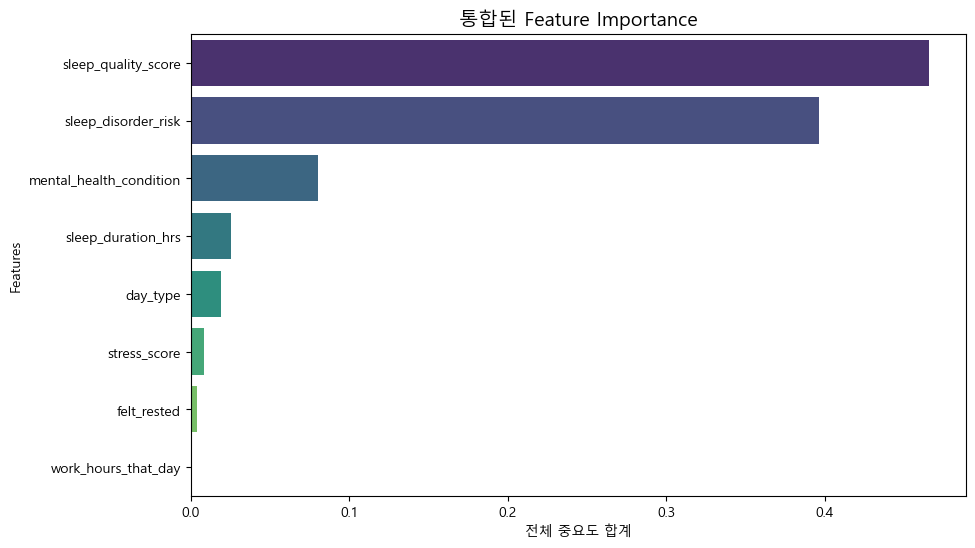

In [75]:
# 5. 통합된 차트 그리기
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grouped_importances, 
    x='Importance', 
    y='Grouped_Feature', 
    palette='viridis',
    hue='Grouped_Feature',
    legend=False
)
plt.title('통합된 Feature Importance', fontsize=14)
plt.xlabel('전체 중요도 합계')
plt.ylabel('Features')
plt.show()

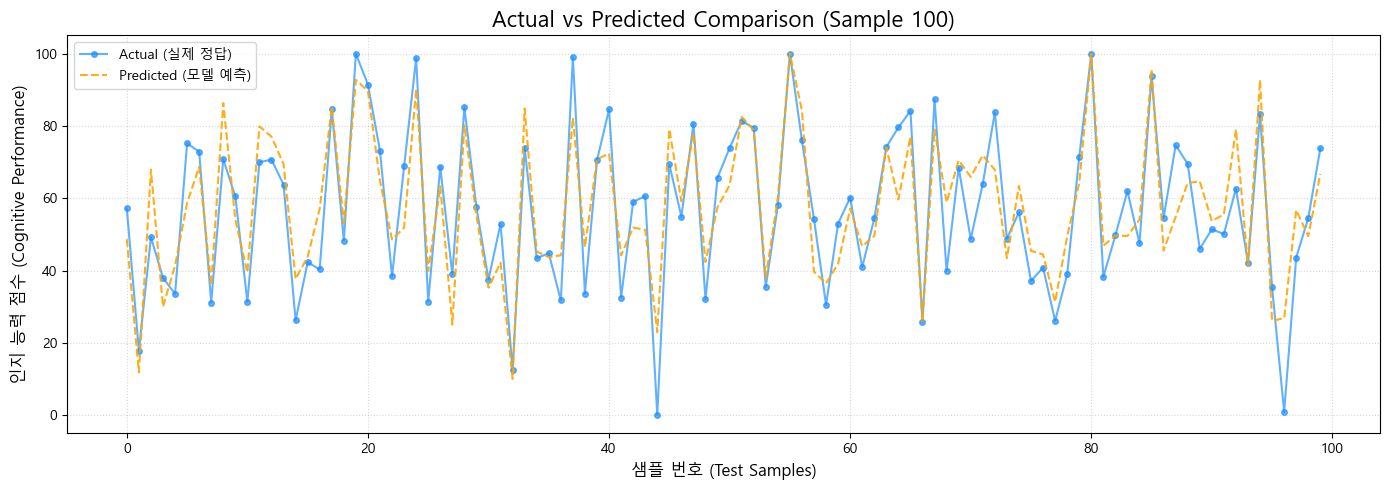

In [76]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:100], label="Actual (실제 정답)", color='dodgerblue', alpha=0.7, marker='o', markersize=4)
plt.plot(y_pred_tuned[:100], label="Predicted (모델 예측)", color='orange', alpha=0.9, linestyle='--')
plt.legend()
# Label
plt.title("Actual vs Predicted Comparison (Sample 100)", fontsize=16)
plt.xlabel("샘플 번호 (Test Samples)", fontsize=12)
plt.ylabel("인지 능력 점수 (Cognitive Performance)", fontsize=12)

plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Dump

In [77]:
import joblib

joblib.dump(encoder, './models/sleep_encoder_v1.pkl')
joblib.dump(scaler, './models/sleep_scaler_v1.pkl')
joblib.dump(best_xgb_model, './models/sleep_model_v1.pkl')

['./models/sleep_model_v1.pkl']

In [78]:
# 1. 각 수치의 평균(Mean) 리스트로 출력
print("Scaler Mean (평균) List:")
print(scaler.mean_.tolist())

# 2. 각 수치의 표준편차(Scale/Std) 리스트로 출력
print("\nScaler Scale (표준편차) List:")
print(scaler.scale_.tolist())

# 3. 어떤 값인지 매칭하기 위해 컬럼 이름들도 함께 출력
print("\nFeature Columns (순서 확인용):")
print(X_train.columns.tolist())

Scaler Mean (평균) List:
[6.422829625, 4.868117499999999, 5.73357375, 7.14386875, 0.71435, 0.28565, 0.6996625, 0.050425, 0.1505125, 0.0994, 0.5408, 0.335075, 0.0834125, 0.0407125, 0.6107, 0.3893]

Scaler Scale (표준편차) List:
[1.2735131681582093, 1.5043364837009539, 1.6178847852399554, 3.475796837816249, 0.4517234524573636, 0.4517234524573636, 0.4584047186643588, 0.2188202901355356, 0.3575730517583085, 0.29919832887233844, 0.49833257970957506, 0.47201667806868863, 0.2765047103464062, 0.19762335981292797, 0.48759154012349315, 0.48759154012349315]

Feature Columns (순서 확인용):
['sleep_duration_hrs', 'sleep_quality_score', 'stress_score', 'work_hours_that_day', 'day_type_1', 'day_type_2', 'mental_health_condition_0', 'mental_health_condition_1', 'mental_health_condition_2', 'mental_health_condition_3', 'sleep_disorder_risk_0', 'sleep_disorder_risk_1', 'sleep_disorder_risk_2', 'sleep_disorder_risk_3', 'felt_rested_0', 'felt_rested_1']
